In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\Banking Dataset\bank\bank-full.csv", sep=';')

In [4]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

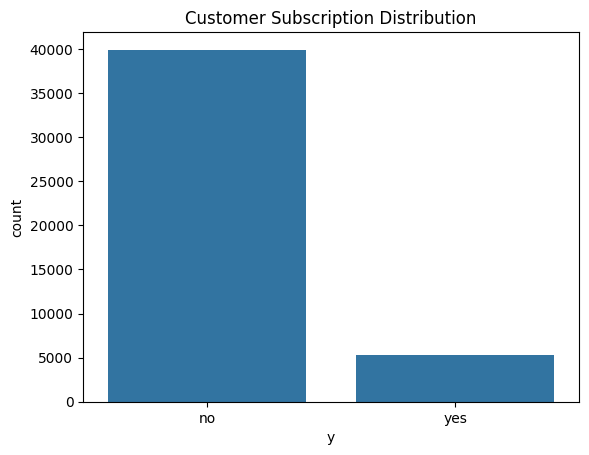

In [8]:
sns.countplot(x='y', data=df)
plt.title("Customer Subscription Distribution")
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv(r"D:\Banking Dataset\bank\bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [11]:
df.replace("unknown", pd.NA, inplace=True)

df.isnull().sum()

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.fillna(df.mode().iloc[0], inplace=True)

In [14]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [15]:
df = pd.get_dummies(df, drop_first=True)

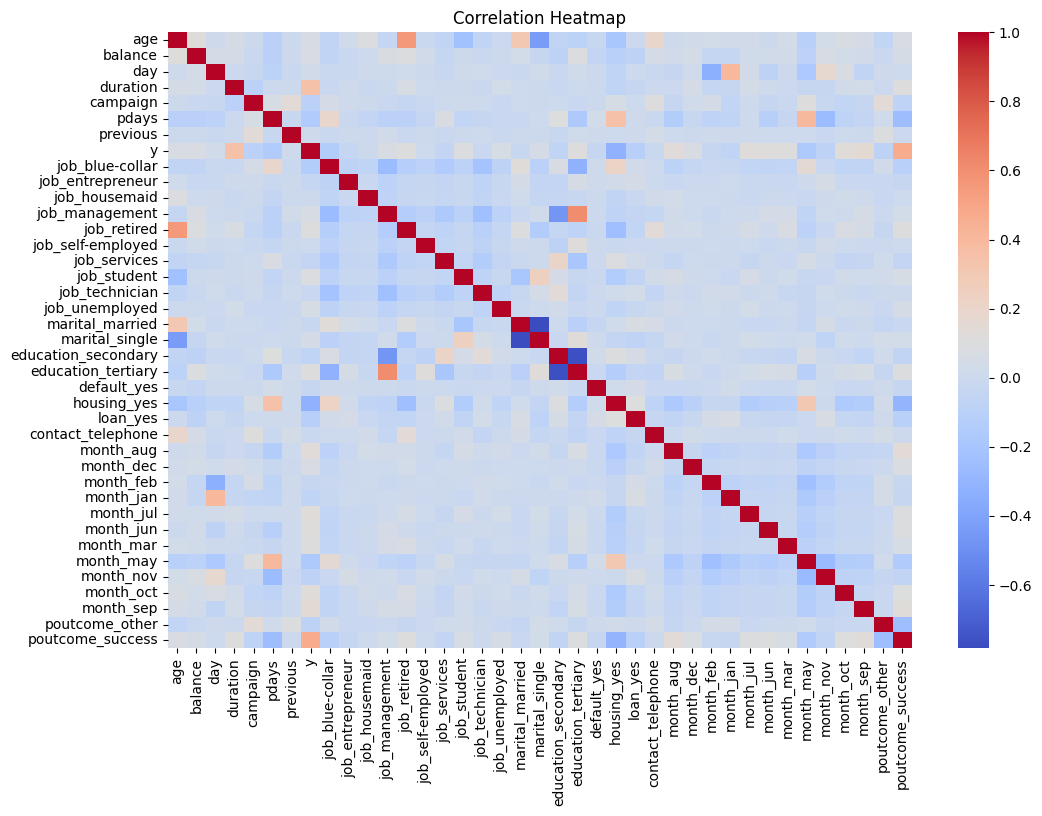

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

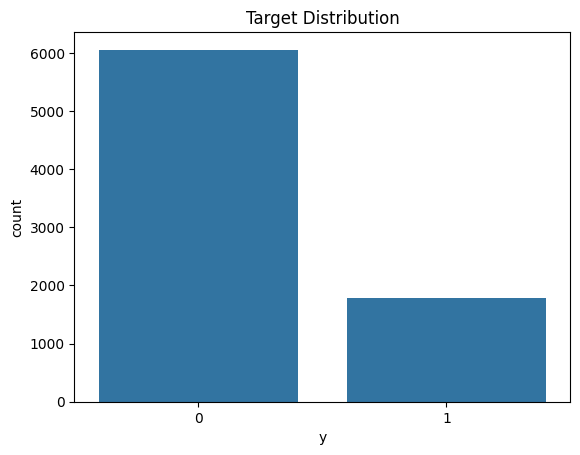

In [17]:
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()

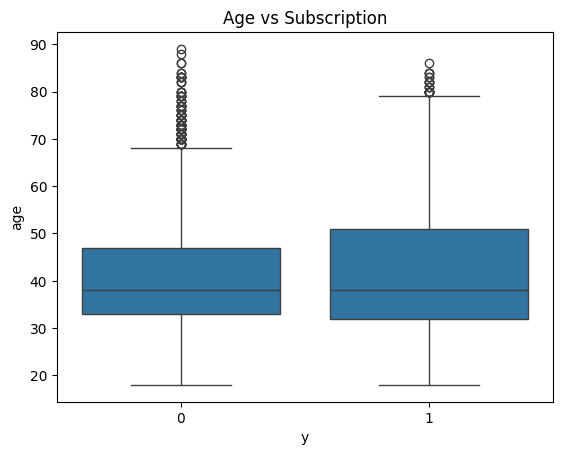

In [18]:
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()

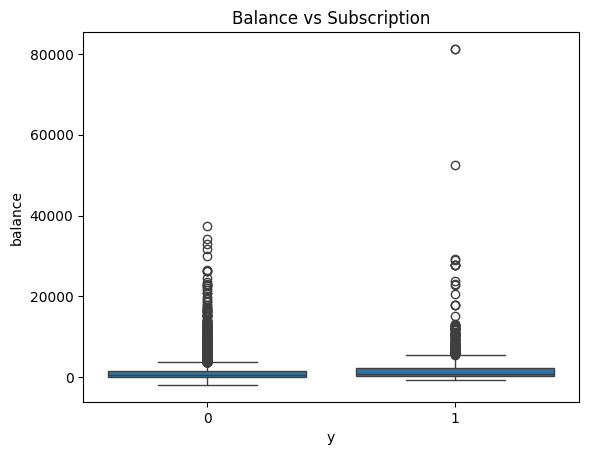

In [19]:
sns.boxplot(x='y', y='balance', data=df)
plt.title("Balance vs Subscription")
plt.show()

In [20]:
df.to_csv("processed_data.csv", index=False)

In [21]:
import pandas as pd

df = pd.read_csv("processed_data.csv")

In [22]:
X = df.drop('y', axis=1)
y = df['y']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

C:\Users\SATWIK\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [26]:
import pandas as pd

df = pd.read_csv("processed_data.csv")

In [27]:
X = df.drop('y', axis=1)
y = df['y']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
from sklearn.metrics import accuracy_score

lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8317399617590823
Random Forest Accuracy: 0.8572339069471001


In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

C:\Users\SATWIK\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:26:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [33]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [34]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [ ]:
pip install --upgrade pip

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [38]:
from sklearn.metrics import accuracy_score

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.851497769279796


In [40]:
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_pred = lr.predict(X_test_scaled)

# Random Forest
rf_pred = rf.predict(X_test)

# XGBoost
xgb_pred = xgb.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

Logistic Regression Accuracy: 0.8317399617590823
Random Forest Accuracy: 0.8572339069471001
XGBoost Accuracy: 0.851497769279796


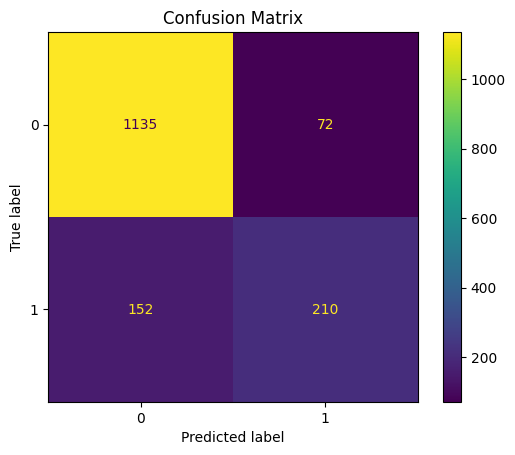

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = rf  # change based on your result

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1207
           1       0.74      0.58      0.65       362

    accuracy                           0.86      1569
   macro avg       0.81      0.76      0.78      1569
weighted avg       0.85      0.86      0.85      1569



In [44]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

best_model = None
best_score = 0

for name, model in models.items():

    # Use scaled data only for Logistic Regression
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    score = accuracy_score(y_test, y_pred)

    print(f"{name}: {score:.4f}")

    if score > best_score:
        best_score = score
        best_model = model

print("\nBest Model Selected:")
print(best_model)

Logistic Regression: 0.8317
Random Forest: 0.8572
XGBoost: 0.8515

Best Model Selected:
RandomForestClassifier(random_state=42)


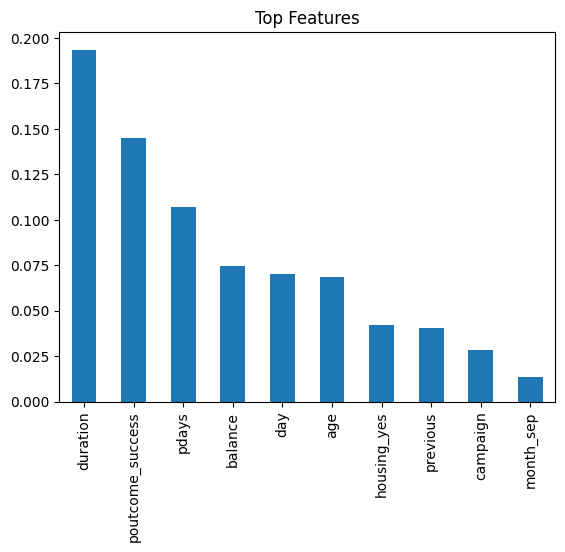

In [45]:
import pandas as pd

importance = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

In [46]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [47]:
loaded_model = joblib.load("best_model.pkl")

In [48]:
def predict_customer(input_data):
    input_df = pd.DataFrame([input_data])

    # Match training columns
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # If best model is Logistic Regression, scale input
    if type(loaded_model).__name__ == "LogisticRegression":
        loaded_scaler = joblib.load("scaler.pkl")
        input_df = loaded_scaler.transform(input_df)

    prediction = loaded_model.predict(input_df)

    return "Yes - Customer likely to subscribe" if prediction[0] == 1 else "No - Customer unlikely to subscribe"

In [49]:
sample_customer = X.iloc[0].to_dict()

result = predict_customer(sample_customer)

print(result)

No - Customer unlikely to subscribe


In [50]:
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [51]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [52]:
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']

In [53]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']